What's inside the zip dataset folder

In [1]:
import zipfile
import os

def unzip_and_print_info(zip_path, extract_to):
    # Open the zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        file_list = zip_ref.infolist()

        print(f"\nZIP file: {zip_path}")
        print(f"Total files inside: {len(file_list)}\n")

        for file in file_list:
            file_name = file.filename
            file_size = file.file_size              # Uncompressed size (bytes)
            compressed_size = file.compress_size    # Compressed size (bytes)
            file_extension = os.path.splitext(file_name)[1]

            print(f"Name: {file_name}")
            print(f"Format: {file_extension}")
            print(f"Size: {file_size} bytes")
            print(f"Compressed size: {compressed_size} bytes")
            print("-" * 40)

        # Extract all files
        zip_ref.extractall(extract_to)
        print(f"\nFiles extracted to: {extract_to}")

# Example usage
zip_file_path = "./Flukeprint_detect.v1i.coco-segmentation.zip"
extract_folder = "24_02_dataset"

unzip_and_print_info(zip_file_path, extract_folder)


ZIP file: ./Flukeprint_detect.v1i.coco-segmentation.zip
Total files inside: 14

Name: README.dataset.txt
Format: .txt
Size: 151 bytes
Compressed size: 128 bytes
----------------------------------------
Name: README.roboflow.txt
Format: .txt
Size: 1010 bytes
Compressed size: 546 bytes
----------------------------------------
Name: train/
Format: 
Size: 0 bytes
Compressed size: 0 bytes
----------------------------------------
Name: train/_annotations.coco.json
Format: .json
Size: 21277 bytes
Compressed size: 6891 bytes
----------------------------------------
Name: train/video_001_event1_A002_500_t-00000s_01_jpg.rf.8a958210d0c7c29fd721f77f48ca9876.jpg
Format: .jpg
Size: 9626 bytes
Compressed size: 9626 bytes
----------------------------------------
Name: train/video_001_event1_A002_510_t-00010s_jpg.rf.aab0f819aa6718a10096c3ed8226c032.jpg
Format: .jpg
Size: 10125 bytes
Compressed size: 10125 bytes
----------------------------------------
Name: train/video_001_event1_A002_530_t-00030s_jpg

How the .json look like

In [2]:
import json

with open("24_02_dataset/train/_annotations.coco.json") as f:
    data = json.load(f)

print(data.keys())          # see structure
print(data["categories"])   # see classes
print(len(data["annotations"]))

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
[{'id': 0, 'name': 'flukeprints', 'supercategory': 'none'}, {'id': 1, 'name': 'flukeprints', 'supercategory': 'flukeprints'}]
53


Dsiplay only the images

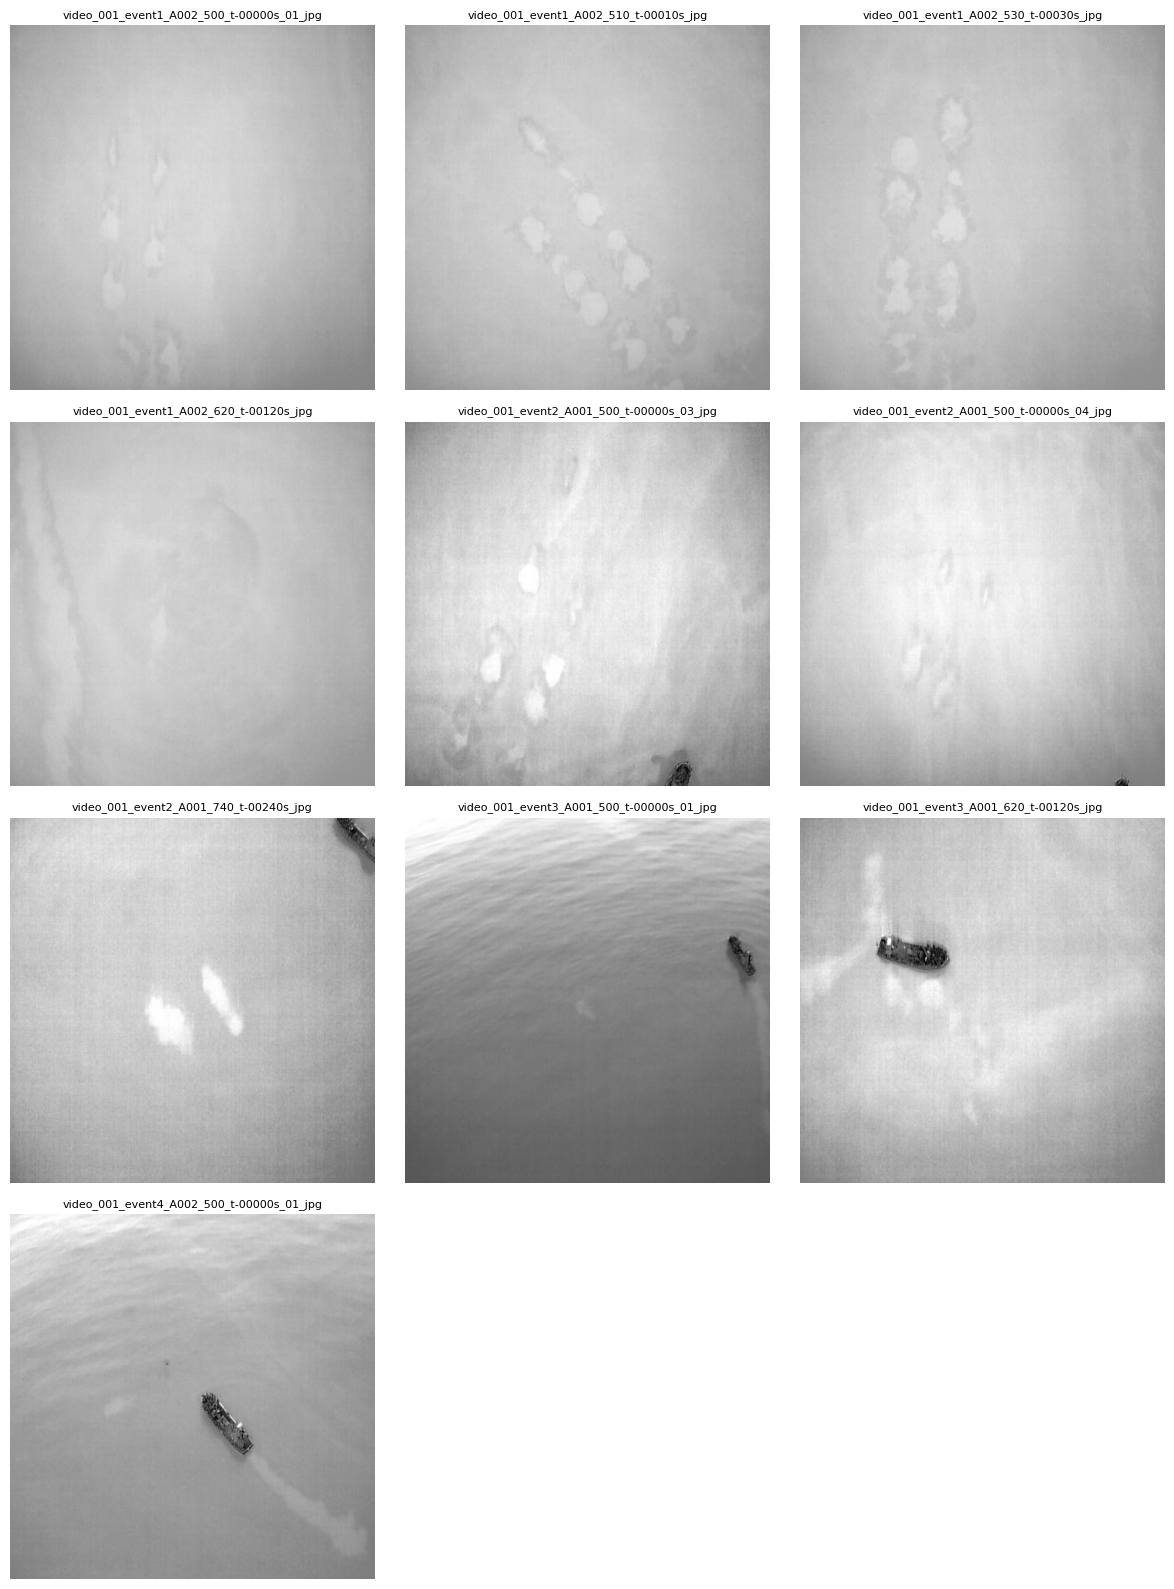

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_folder = "24_02_dataset/train"
image_files = [f for f in os.listdir(image_folder) if f.endswith(".jpg")]

cols = 3
rows = (len(image_files) + cols - 1) // cols

plt.figure(figsize=(12, 4 * rows))

for i, img_name in enumerate(image_files):
    img_path = os.path.join(image_folder, img_name)
    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    clean_name = img_name.split(".rf.")[0]
    plt.title(clean_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

Display annotations:

from the .json --> dict_keys(['info', 'licenses', 'categories', 'images', 'annotations']) 

In [4]:
# Path to annotation file
annotation_file = os.path.join("24_02_dataset", "train", "_annotations.coco.json")

# Load JSON
with open(annotation_file) as f:
    coco_data = json.load(f)

# Print top-level keys
print("Top-level keys:", coco_data.keys())
print("\nNumber of images:", len(coco_data["images"]))
print("Number of annotations:", len(coco_data["annotations"]))
print("Categories:", coco_data["categories"])

# Print first image info
print("\nFirst image info:")
print(coco_data["images"][0])

# Print first annotation info
print("\nFirst annotation info:")
print(coco_data["annotations"][0])

# Print first category info
print("\nFirst category info:")
print(coco_data["categories"][0])

Top-level keys: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

Number of images: 10
Number of annotations: 53
Categories: [{'id': 0, 'name': 'flukeprints', 'supercategory': 'none'}, {'id': 1, 'name': 'flukeprints', 'supercategory': 'flukeprints'}]

First image info:
{'id': 0, 'license': 1, 'file_name': 'video_001_event4_A002_500_t-00000s_01_jpg.rf.652c7d83442e2e6fbf27088899fe968f.jpg', 'height': 432, 'width': 432, 'date_captured': '2026-01-05T10:05:36+00:00', 'extra': {'user_tags': ['video_001'], 'name': 'video_001_event4_A002_500_t-00000s_01.jpg'}}

First annotation info:
{'id': 1, 'image_id': 0, 'category_id': 1, 'bbox': [112, 213, 35.37, 25.299], 'area': 894.826, 'segmentation': [[130.95, 232.36, 132.84, 228.988, 134.19, 226.289, 143.1, 225.277, 147.42, 220.555, 146.61, 214.145, 137.16, 212.796, 125.55, 216.844, 112.725, 226.125, 112.05, 237.094, 114.48, 238.095, 123.93, 233.373, 130.95, 232.36]], 'iscrowd': 0}

First category info:
{'id': 0, 'name': 'flukep

Display images with their annotations:

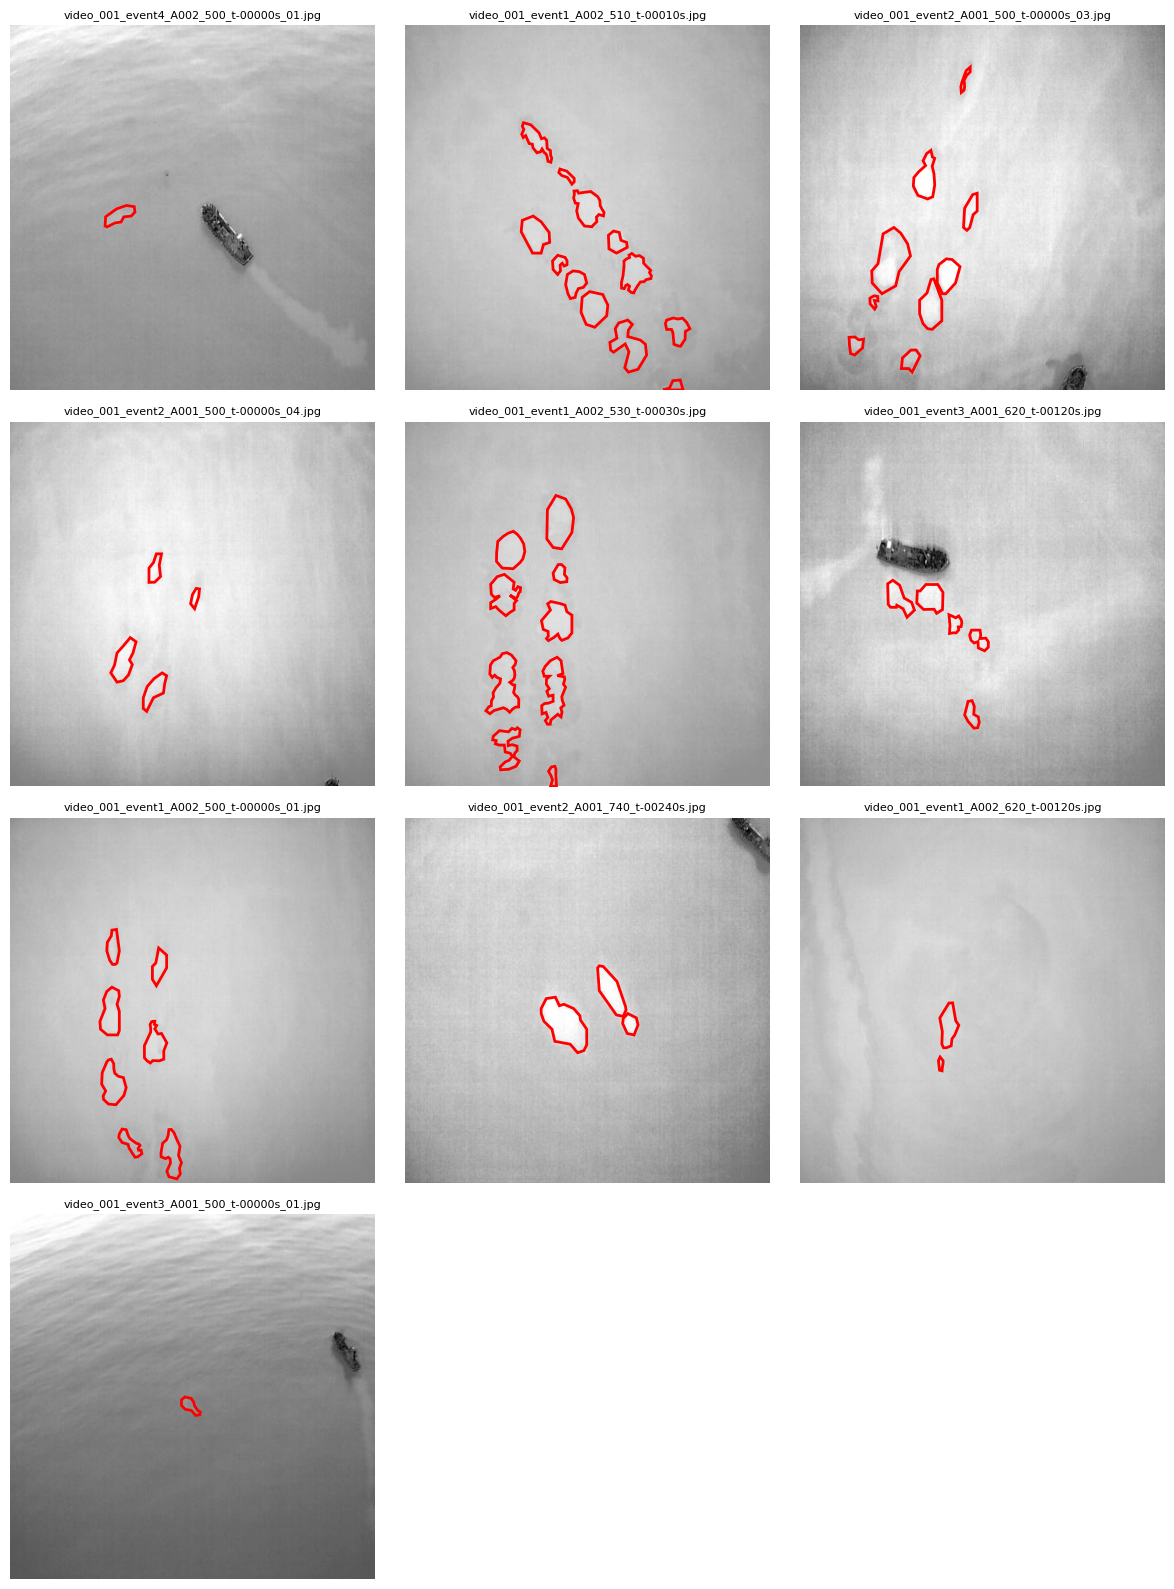

In [5]:
import matplotlib.patches as patches
import numpy as np

# Paths
image_folder = "24_02_dataset/train"
annotation_file = os.path.join(image_folder, "_annotations.coco.json")

# Load COCO annotations
with open(annotation_file) as f:
    coco_data = json.load(f)

images = coco_data["images"]
annotations = coco_data["annotations"]
categories = {cat["id"]: cat["name"] for cat in coco_data["categories"]}

# Map image_id to its annotations
ann_map = {}
for ann in annotations:
    img_id = ann["image_id"]
    if img_id not in ann_map:
        ann_map[img_id] = []
    ann_map[img_id].append(ann)

# Grid display
cols = 3
rows = (len(images) + cols - 1) // cols
plt.figure(figsize=(12, 4 * rows))

for i, img_info in enumerate(images):
    img_path = os.path.join(image_folder, img_info["file_name"])
    img = Image.open(img_path)

    # Use the clean name from extra['name']
    clean_name = img_info.get("extra", {}).get("name", img_info["file_name"])

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(clean_name, fontsize=8)
    plt.axis("off")

    img_id = img_info["id"]

    # Draw segmentation polygons
    if img_id in ann_map:
        for ann in ann_map[img_id]:
            segmentation = ann["segmentation"]
            category = categories.get(ann["category_id"], "unknown")

            for seg in segmentation:
                polygon = np.array(seg).reshape(-1, 2)
                plt.gca().add_patch(
                    patches.Polygon(
                        polygon,
                        fill=False,
                        edgecolor='red',
                        linewidth=2,
                        label=category
                    )
                )

plt.tight_layout()
plt.show()